# Laboratory 11: A minimal implementation of DALL-E

This laboratory covers:

* How DALL-E is trained to generate images from text descriptions
* How a pretrained BART encoder transforms a text prompt into dense embeddings
* How an autoregressive BART decoder uses those embeddings to predict a sequence of image tokens
* How a VQGAN decoder converts image tokens into visual patches and reconstructs them into a complete high-resolution image

OpenAI's DALL-E is one of the earliest and most influential text-to-image generators. It is a large-scale Transformer that can generate high-resolution images from natual language prompts. DALL-E stands at the intersection of two technologies in modern AI: powerful autoregressive language models and vector-quantized representations of visual information. Yet, for many learners, practitioners, and researchers, the full DALL-E model remains out of reach due to its proprietary nature.

To foster deeper understanding and democratize access, the open-source community has stepped up, replicating DALL·E's core ideas with public tools and datasets. Notably, the DALL-E mini project and its streamlined PyTorch reimplementation, min-DALL-E, have made it possible for anyone to explore the mechanics of Transformer-based text-to-image generation and even build their own models from scratch.

In this laboratory, we will learn to build a Transformer-based text-to-image generator from scratch, not treating it as a black box, but instead working through every stage of the process. We will learn how a Bidirectional and Autoregressive Transformer (BART) encoder transforms a text prompt into rich vector embeddings, how the BART decoder translates those embeddings into a sequence of image tokens, and finally, how a Vector-Quantized Generative Adversarial Network (VQGAN) decoder reconstructs those tokens into a complete high-resolution image.

To make the process tangible, we will use a simple, vivid prompt, “panda with top hat reading a book”, and go through each stage of the pipeline. Along the way, we will see not only the final result, but also the intermediate outputs: what the model produces after generating just $32$, $64$, or $128$ of the eventual $256$ image tokens. This incremental visualization will give us an intuitive grasp of how the image gradually takes shape as the model “paints” patch by patch.

By the end of the laboratory, we will not only understand the architecture and training procedure of DALL-E-like models, but we will also gain hands-on experience generating images from text prompts using the min-DALL-E implementation. Along the way, we will deepen our understanding of key generative modeling concepts such as vector quantization, autoregressive decoding, temperature scaling, and top-K sampling.


# 1. Tokenizing and encoding the text prompt

Before we generate an image using a prompt, we must first convert the input text
prompt into a form that the model understands. This process involves the following
steps:

1. Download the tokenizer vocabulary files.
2. Initialize the tokenizer.
3. Tokenize the text prompt.
4. Pad and format the tokenized input.
5. Encode the tokens into text embeddings using a pretrained BART encoder.

We will walk through each of these steps using the prompt “panda with top hat reading a
book” as our running example. This simple, vivid example produces interesting visual output.

## 1.1.	Tokenizing the text prompt

First, we should clone the min-DALL-E GitHub repository by Brett Kuprel, https://github.com/kuprel/min-dalle:

In [1]:
!git clone https://github.com/kuprel/min-dalle

Cloning into 'min-dalle'...
remote: Enumerating objects: 1595, done.
remote: Counting objects: 100% (373/373), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 1595 (delta 298), reused 277 (delta 277), pack-reused 1222 (from 3)
Receiving objects: 100% (1595/1595), 48.61 MiB | 26.69 MiB/s, done.
Resolving deltas: 100% (992/992), done.


We will see a folder `min-dalle`, which contains all files and modules
in the min-DALL-E project.

Next, we create a local folder to store the pretrained models:

In [13]:
import os

folder="files/DALLE"
if not os.path.exists(folder):    #If the folder files/DALLE does not exist, create the folder
    os.makedirs(folder)

We should see a new directory `files/DALLE` created after running
the preceding code cell. We will place pretrained models in this folder later.

The tokenizer used by min-DALL-E is based on Byte Pair Encoding (BPE), and it
relies on two files: `vocab.json`, which maps tokens to IDs, and `merges.txt`, which defines
how subword units are merged during tokenization. These files are hosted on Hugging
Face and must be downloaded to initialize the tokenizer.

In [14]:
import requests

url='https://huggingface.co/kuprel/min-dalle/resolve/main/'
vocab_path=folder+"/vocab.json"
merges_path=folder+"/merges.txt"

if not (os.path.exists(vocab_path)
    and os.path.exists(merges_path)):    #If either vocab.json or merges.txt are not present, start downloading
    print("downloading tokenizer parameters")

    vocab = requests.get(url + 'vocab.json')
    merges = requests.get(url + 'merges.txt')
    with open(vocab_path, 'wb') as f:
        f.write(vocab.content)
    with open(merges_path, 'wb') as f:    #Downloads the two files and saves them
        f.write(merges.content)
else:    #Skips if the two files have already been downloaded
    print("tokenizer parameters have already been downloaded")

tokenizer parameters have already been downloaded


This code block checks whether the tokenizer files already exist. If
not, it downloads them from the official min-DALL-E Hugging Face repository and
saves them locally for later use. If we go to the `files/DALLE` folder, we will see the two
tokenizer files, `vocab.json` and `merges.txt`.

In [4]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 19.2 MB/s eta 0:00:00


In [15]:
import sys
sys.path.append("min-dalle")    #Adds the min-dalle folder to Python’s search path

import json
from min_dalle.text_tokenizer import TextTokenizer    #Imports the TextTokenizer class from the min-DALL-E GitHub repository

print("intializing TextTokenizer")
with open(vocab_path, 'r', encoding='utf8') as f:
    vocab = json.load(f)
with open(merges_path, 'r', encoding='utf8') as f:
    merges = f.read().split("\n")[1:-1]    #Loads the tokenizer files
tokenizer = TextTokenizer(vocab, merges)    #Initializes the tokenizer

intializing TextTokenizer


To make sure Python can access and import modules from the min-DALL-E GitHub
repository, we add the `min-dalle` folder to Python's search path using the `sys` library.
We then import the `TextTokenizer` class from the repository and load up the two
tokenizer files. We initialize the tokenizer by using the two files as input in the `TextTokenizer`
class.

This tokenizer converts raw text into a sequence of token IDs using BPE. It also handles
special tokens such as `<s>` (start of sequence), `</s>` (end of sequence), and `<pad>`
(padding), which are required for the model to understand context and batch input
correctly. We inspect the first few entries in the vocabulary to get a sense of how tokens
are indexed:

In [16]:
print({k:v for k,v in vocab.items() if v<10})

{'<s>': 0, '<pad>': 1, '</s>': 2, '<unk>': 3, '<mask>': 4, '"': 5, '$': 6, '%': 7, '&': 8, "'": 9}


As we can see, the start of the sentence token is mapped to index `0`. The padding
token is mapped to index `1`. The end of the sentence token is mapped to index `2`.
These IDs are used internally by the model and must match those in the pretrained
weights for inference to work properly. Now, we will tokenize our prompt.

In [17]:
text = "panda with top hat reading a book"
token_ids = tokenizer.tokenize(text)    #Tokenizes text to get token IDs
print("Token IDs:", token_ids)

idx2token = {v: k for k, v in vocab.items()}    #Reverses the vocab dictionary to map IDs to tokens

raw_tokens = [idx2token.get(i, "<unk>") for i in token_ids]    #Maps token IDs to raw tokens
print("Raw Tokens:", raw_tokens)

Token IDs: [0, 8418, 208, 479, 2583, 4132, 58, 407, 2]
Raw Tokens: ['<s>', 'Ġpanda', 'Ġwith', 'Ġtop', 'Ġhat', 'Ġreading', 'Ġa', 'Ġbook', '</s>']


The `tokenizer.tokenize()` function in min-DALL-E returns token IDs, not raw token
strings. However, we have recovered the raw subword tokens by reversing the vocab dictionary.

The token IDs start with `0`, corresponding to the token '`<s>`', signaling the start of the
sentence. The last token ID is `2`, corresponding to the token '`</s>`', indicating the
end of the sequence. The prompt itself is divided into seven raw tokens, ['`Ġpanda`',
'`Ġwith`', '`Ġtop`', '`Ġhat`', '`Ġreading`', '`Ġa`', '`Ġbook`'], where `Ġ` indicates a word
boundary (space). This is a convention in BPE tokenizers used by models such as GPTs
and BART.

Transformer models require fixed-length sequences for batching and efficient computation.
We will create a padded input of length $64$ and prepare two sequences: one
for the actual text and another unconditional one for classifier-free guidance (CFG; as
discussed in Laboratory 5).

In [18]:
import numpy, torch

device="cuda" if torch.cuda.is_available() else "cpu"

text_tokens = numpy.ones((2, 64), dtype=numpy.int32)    #Initializes a NumPy array filled with the <pad> token (index 1)
text_tokens[0, :2] = [token_ids[0], token_ids[-1]]    #Creates the unconditional prompt, with just two tokens <s> and </s>
text_tokens[1, :len(token_ids)] = token_ids    #Creates the padded conditional prompt
text_tokens = torch.tensor(text_tokens,
    dtype=torch.long, device=device)    #Converts the input to a PyTorch long tensor
print(text_tokens)

tensor([[   0,    2,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1],
        [   0, 8418,  208,  479, 2583, 4132,   58,  407,    2,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1]], device='cuda:0')


This creates a $2 \times 64$ tensor: one row for the unconditional prompt and one for the real
prompt, both padded to a uniform length.

The first row in the output represents the unconditional prompt, which is essentially
an empty string. The second row represents the conditional prompt. Both are padded
to a length of $64$ elements.

## 1.2.	Encoding the text prompt

The next step is to use the pretrained BART encoder to transform our tokenized input
into high-dimensional vector embeddings. To that end, we download the pretrained
weights for the BART encoder from Hugging Face like this:

In [19]:
encoder_path=folder+"/encoder.pt"

if not os.path.exists(encoder_path):    #If the weights are not available locally, downloads them from Hugging Face
    print("downloading encoder parameters")
    ws = requests.get(url + 'encoder.pt')
    with open(encoder_path, 'wb') as f:
        f.write(ws.content)
else:    #Otherwise, skips downloading
    print("encoder parameters have already been downloaded")

encoder parameters have already been downloaded


This code block ensures that the pretrained BART encoder weights (used in the
min-DALL-E model) are available locally. If they are not, it downloads them from Hugging
Face. These weights are essential for converting text prompts into dense vector
embeddings.

To create a BART encoder, we instantiate the `DalleBartEncoder` class in the local
module file `dalle_bart_encoder.py` in the `min-dalle/min_dalle/models` folder. The
following code shows how.

In [23]:
from min_dalle.models import DalleBartEncoder

torch.manual_seed(42)    #Fixes the random state so results are reproducible
dtype = "float16"
print("initializing DalleBartEncoder")
encoder = DalleBartEncoder(    #Instantiates the DalleBartEncoder class to create the BART encoder
    attention_head_count = 32,
    embed_count = 2048,    #Text embeddings have a dimension of 2048
    glu_embed_count = 4096,
    text_token_count = 64,    #Text prompts have 64 tokens
    text_vocab_count = 50272,
    layer_count = 24,
    device=device
).to(getattr(torch, dtype)).eval()
params = torch.load(encoder_path)
encoder.load_state_dict(params, strict=False)    #Loads the pretrained weights
del params
encoder = encoder.to(device)

initializing DalleBartEncoder


This code block sets up and loads the pretrained BART encoder in min-DALL-E. We
set a fixed random seed for reproducibility and use the data type `float16` for faster
inference. Now we can encode the unconditional prompt and the text prompt:

In [11]:
with torch.amp.autocast("cuda", dtype=getattr(torch, dtype)):
    encoder_state = encoder.forward(text_tokens)
torch.cuda.empty_cache()
print("Shape of the text embeddings:", encoder_state.shape)

Shape of the text embeddings: torch.Size([2, 64, 2048])


The output tensor contains the encoded embeddings for both the unconditional and
conditional prompts. Each of the $64$ tokens is represented as a $2,048$-dimensional vector.
These embeddings will be used in the next step to condition the image token generation.

# 2. Iterative prediction of image tokens

Now that we have obtained text embeddings using the BART encoder, it's time to generate
image tokens, one of the most critical steps in the min-DALL-E pipeline. Next, we will do the following:

* Load the pretrained BART decoder.
* Configure sampling parameters.
* Use the decoder to predict a sequence of image tokens autoregressively.
* Capture intermediate token outputs for visualization later.

This process effectively converts text into a “visual language” that the VQGAN decoder
will later reconstruct into a high-resolution image.

## 2.1. Loading the pretrained BART decoder

Just like the encoder, the decoder in min-DALL-E is based on a Transformer architecture.
Its role is to generate a sequence of $256$ image tokens, one at a time, conditioned
on the text embeddings we computed in the previous section. We first download the
pretrained weights if they are not already saved locally:

In [12]:
torch.save(text_tokens, "files/DALLE/text_tokens.pt")
torch.save(encoder_state, "files/DALLE/encoder_state.pt")

In [13]:
exit()

In [1]:
import os

folder="files/DALLE"

import sys
sys.path.append("min-dalle")

import numpy, torch

device="cuda" if torch.cuda.is_available() else "cpu"

dtype = "float16"

text_tokens=torch.load("files/DALLE/text_tokens.pt")
encoder_state=torch.load("files/DALLE/encoder_state.pt")

import requests

url='https://huggingface.co/kuprel/min-dalle/resolve/main/'

In [2]:
decoder_path=folder+"/decoder.pt"

if not os.path.exists(decoder_path):    #Downloads the pretrained BART decoder weights if they are not saved locally
    print("downloading decoder parameters")
    weights = requests.get(url + 'decoder.pt')
    with open(decoder_path, 'wb') as f:
        f.write(weights.content)
else:
    print("decoder parameters have already been downloaded")

decoder parameters have already been downloaded


Next, we create a BART decoder by instantiating the `DalleBartDecoder` class from
the local module.

In [3]:
from min_dalle.models import DalleBartDecoder

print("initializing DalleBartDecoder")
decoder = DalleBartDecoder(    #Creates a BART decoder
    image_vocab_count = 16415,
    attention_head_count = 32,
    embed_count = 2048,
    glu_embed_count = 4096,
    layer_count = 24,
    device=device
).to(getattr(torch, dtype)).eval()
params = torch.load(decoder_path)    #Loads the trained weights
decoder.load_state_dict(params, strict=False)
del params
decoder = decoder.to(device)

initializing DalleBartDecoder


We create the BART decoder and load the trained weights. The decoder is trained to
predict image tokens autoregressively, that is, one token at a time, using all previously
generated tokens and the encoded text as input.

## 2.2. Predicting image tokens using the BART decoder

We are now ready to generate image tokens. The image is composed of $256$ discrete
tokens, arranged in a $16 \times 16$ grid, representing patches of the final image. These
tokens are generated sequentially using the decoder. Before sampling, we need to set
up several components:

In [4]:
attention_mask=text_tokens.not_equal(1)[:, None, None, :]    #Creates an attention mask
attention_state=torch.zeros(size=(24,4,256,2048),    #Creates an attention_state cache
    device=device)
image_tokens=torch.full((1, 256 + 1),    #Creates a sequence of 257 image tokens, filled with a special placeholder token
    2 ** 14 - 1,dtype=torch.long,device=device)

We create a tensor `attention_mask`, which is used to ensure that the model ignores
padding tokens (index $1$) when computing attention scores. It is shaped to match the
decoder's expected input for causal self-attention. We then create the `attention_state`
tensor to cache the decoder's internal attention activations across $24$ layers and four
attention heads. Finally, the tensor `image_tokens` holds the generated sequence of
tokens. It is initialized with a special placeholder token (index $16383$) and will be filled
with valid image tokens as generation proceeds.

To control the creativity and quality of the output, min-DALL-E uses a few key sampling
strategies:

In [5]:
token_indices=torch.arange(256,device=device)
temperature=0.5    #Sets the temperature parameter to 0.5
top_k=128    #Sets the top-K sampling parameter to 128
supercondition_factor=4    #Sets the supercondition factor to 4
settings = torch.tensor(
    [temperature, top_k, supercondition_factor],
    dtype=torch.float32,device=device)

The temperature parameter controls the randomness of the predictions of the
trained model. A high temperature (greater than $1$, e.g., $1.5$) makes the generated
output more creative, while a low temperature (less than $1$, e.g., $0.6$) makes the text
more confident and predictable. Top-K sampling is a method where we select the next token from the top K most probable tokens, rather than selecting from the
entire vocabulary. A small value of K leads to the selection of highly likely tokens in
each step, which, in turn, makes the generated text less creative and more coherent.
The supercondition factor balances the influence of the unconditional and conditional
prompts during CFG. Higher values increase the model's adherence to the
input text.

Now comes the core loop. We generate tokens one at a time using the decoder, feeding
in the current token and updating the internal state.

In [6]:
from copy import deepcopy

imgtokens=[]    #Creates a list imgtokens to store intermediate steps
for i in range(256):    #Iterates 256 steps
    torch.cuda.empty_cache()
    with torch.amp.autocast("cuda",dtype=getattr(torch, dtype)):
        image_tokens[:, i + 1], attention_state = decoder.sample_tokens(    #Predicts the next token using previous tokens and the text embeddings
            settings=settings,
            attention_mask=attention_mask,
            encoder_state=encoder_state,
            attention_state=attention_state,
            prev_tokens=image_tokens[:, [i]],
            token_index=token_indices[[i]])
        imgtokens.append(deepcopy(image_tokens))

We iteratively predict the $256$ image tokens. In the first iteration, we predict the image
token for the patch in the top-left corner of the image. In the second iteration, we predict
the image token for the patch in the top row, second column in the image grid,
and so on. We have created a list `imgtokens` to contain all intermediate steps so that later
we can visualize how the image is created step-by-step.

By autoregressively generating each token, min-DALL-E constructs an image in
a step-by-step manner, similar to how GPT generates text. This gives us fine-grained
control over the generation process and allows us to inspect intermediate outputs. For
instance, we can visualize what the image looks like after $32$, $64$, or $128$ tokens to understand
how the image evolves as more information is added.

These image tokens are still abstract. They represent positions in a learned VQGAN
codebook. Next, we will decode them into visual patches and stitch them into a full image
using the pretrained VQGAN detokenizer.

# 3. Converting image tokens to high-resolution images

By now, we have taken a text prompt, encoded it using a BART encoder, and used a
decoder to generate a sequence of $256$ image tokens, each representing a patch in a $16
\times 16$ image grid. However, these tokens are not directly viewable. They are indices pointing
to a codebook learned by a VQGAN. To visualize the final image, we must convert
these tokens into actual pixels, a process known as detokenization.

Next, we will use a pretrained VQGAN decoder, also known as the detokenizer, to
convert the sequence of tokens into a high-resolution color image. We will first generate
the complete image, then visualize how the image evolves step-by-step, and
finally create an animation that shows how a picture is literally built one token at a
time.

## 3.1. Loading the pretrained VQGAN detokenizer


The VQGAN detokenizer is a convolutional neural network trained to map discrete
token indices back to their corresponding image patches. When stitched together,
these patches form the final image, as we have done in Laboratory 10.

Like the BART encoder and decoder, the VQGAN detokenizer must be initialized
with pretrained weights. The detokenizer is defined in the `vqgan_detokenizer.py` module
of the min-DALL-E repository. We begin by ensuring the detokenizer weights are
available:

In [7]:
detokenizer_path=folder+"/detoker.pt"
if not os.path.exists(detokenizer_path):    #Downloads the pretrained weights for the VQGAN detokenizer
    print("downloading detokenizer parameters")
    ws = requests.get(url + 'detoker.pt')
    with open(detokenizer_path, 'wb') as f:
        f.write(ws.content)
else:
    print("detokenizer parameters have already been downloaded")

downloading detokenizer parameters


This code block checks whether the file `detoker.pt` exists locally. If not, it downloads
the file from the min-DALL-E repository on Hugging Face. Next, we initialize the detokenizer
and load its parameters:

In [8]:
from min_dalle.models import VQGanDetokenizer

print("initializing VQGanDetokenizer")
detokenizer = VQGanDetokenizer().eval()    #Initializes the VQGAN detokenizer and set it to evaluation mode
params = torch.load(detokenizer_path)
detokenizer.load_state_dict(params)    #Loads the pretrained weights
del params
detokenizer = detokenizer.to(device)

initializing VQGanDetokenizer


The detokenizer is set to `.eval()` mode to ensure that dropout and other training
behaviors are disabled during inference.

## 3.2. Visualizing the intermediate and final high-resolution outputs

Now that our detokenizer is loaded, we can convert the generated image tokens into
an actual image. We first visualize the final image corresponding to all $256$ tokens:

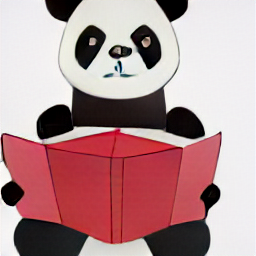

In [9]:
from PIL import Image

torch.cuda.empty_cache()
image = detokenizer.forward(True,
        image_tokens[:, 1:])    #Decodes image tokens to an image tensor (skip the BOS token)
image = image.to(torch.uint8).to('cpu').numpy()    #Converts the image tensor to NumPy arrays
image = Image.fromarray(image)    #Converts NumPy arrays to an actual image using the PIL library
image.save("files/minDALLE.png")
image

The tensor `image_tokens` has $257$ elements;
we skip the first one because it represents
the BOS token. We use the pretrained
VQGAN detokenizer to decode the remaining
$256$ image tokens to an image tensor. We
then convert the image tensor to NumPy
arrays and use the Python Imaging Library
(PIL) to display the final image.

The image shows that the panda, hat,
book, and reading posture are clearly represented,
even though the prompt is informal.
The boundaries between patches are
nearly invisible, highlighting the decoder's
ability to preserve texture, structure, and
style during reconstruction.

To better understand how the image “grows” during generation, we can visualize snapshots
of intermediate outputs. This gives us a more intuitive understanding of what the
model is doing at each decoding step.

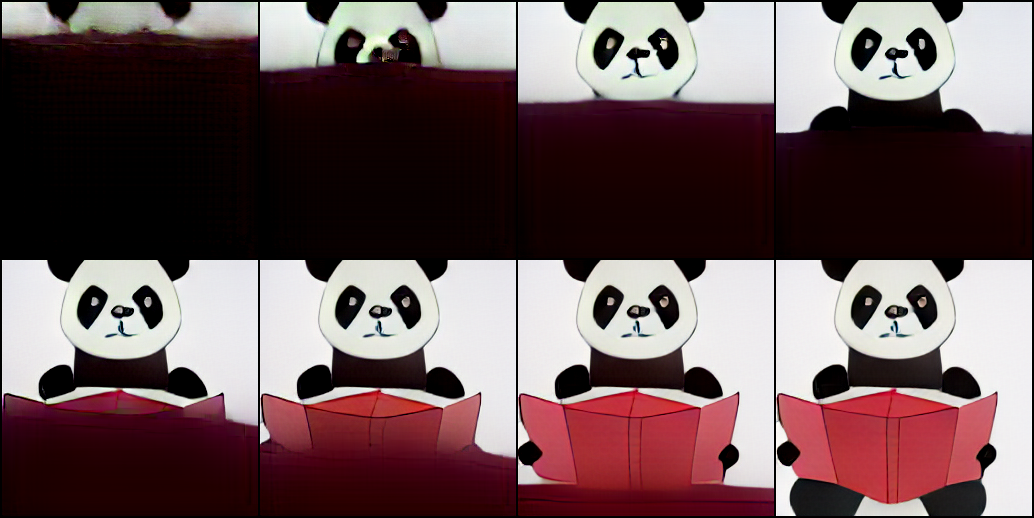

In [10]:
from torchvision.utils import make_grid
from torchvision.transforms import ToPILImage

imgs=[]
for i in range(8):
    torch.cuda.empty_cache()
    images = detokenizer.forward(True,
      imgtokens[32*(i+1)-1][:, 1:])    #Selects images at steps 32, 64, 96, 128, 160, 192, 224, and 256.
    imgs.append(images.permute(2,0,1).to(torch.uint8))
grid=make_grid(imgs,nrow=4)    #Places the 8 images in a 2 x 4 grid
img=ToPILImage()(grid)
img.save("files/minDALLEsteps.png")
img

The image generation takes $256$ steps, with each step predicting one image token. We
select the intermediate image after every $32$ steps, and this results in eight intermediate
images, at steps $32$, $64$, . . ., $224$, and $256$, respectively. We then place these eight images
in a $2 \times 4$ grid, as shown in the figure above. The model divides an image into $256$ patches,
organized in a $16 \times 16$ grid. When generating an image based on a text prompt, the
model first predicts the top-left patch. In the next iteration, the model predicts the
patch next to it, based on the first patch and the prompt. The process is repeated until
we have all the needed patches in the image. In this figure, the top-left subplot shows
the output when $32$ image patches are generated. The second subplot in the top row
shows the output when $64$ patches are generated. The rest of the images show the outputs
when $96$, $128$, . . ., and $256$ patches are generated.

The figure above shows the step-by-step progression of image generation. Each subplot corresponds
to an intermediate image. After $32$ tokens, only the top $1/8$ of the image is present; by $128$ tokens, half of the image is recognizable. The final subplot ($256$
tokens) shows the complete result.

To wrap up, we will animate the full token-by-token generation process using all $256$
intermediate outputs.

In [11]:
vids=[]    #Creates a list vids to store all intermediate images
for i in range(len(imgtokens)):
    torch.cuda.empty_cache()
    images = detokenizer.forward(True,
      imgtokens[i][:, 1:])    #Generates an image in each of the 256 intermediate steps
    image = images.to(torch.uint8).to('cpu').numpy()
    vids.append(Image.fromarray(image))

import imageio
imageio.mimsave("files/minDALLE.gif",    #Uses the imageio library to create an animation
        vids,fps=30)

If we go to the `files` folder, we will see the animation `minDALLE.gif`. We can watch the image form in real time.

The animation serves as an illustration of autoregressive decoding in the generation
process. Unlike traditional Generative Adversarial Networks (GANs), which generate
images in a single pass, models such as DALL-E allow us to peek inside the creative process,
one token at a time.

This marks the completion of the min-DALL-E pipeline: from a natural language
prompt, through encoding and decoding, all the way to pixel-level image generation.

#Exercises

1. Convert the prompt “an underwater fantasy city” into token IDs and then raw tokens.
Name the list of token IDs `token_ids2`.

In [20]:
# Convert the prompt "an underwater fantasy city" into token IDs and then raw tokens
text2 = "an underwater fantasy city"
token_ids2 = tokenizer.tokenize(text2)
print("Token IDs 2:", token_ids2)

# Reverse the vocab dictionary to map IDs to tokens
idx2token = {v: k for k, v in vocab.items()}
raw_tokens2 = [idx2token.get(i, "<unk>") for i in token_ids2]
print("Raw Tokens 2:", raw_tokens2)


Token IDs 2: [0, 101, 10892, 3091, 645, 2]
Raw Tokens 2: ['<s>', 'Ġan', 'Ġunderwater', 'Ġfantasy', 'Ġcity', '</s>']


2. Use the list of token IDs `token_ids2` that was created in Exercise 1 to create a
PyTorch tensor `text_tokens2`. Make sure that `text_tokens2` has a shape of $(2, 64)$,
representing the padded token IDs for the unconditional prompt and the text prompt
“an underwater fantasy city”, respectively. Print out the values of `text_tokens2`.

In [21]:
# Create the padded token tensor of shape (2, 64)
text_tokens2 = numpy.ones((2, 64), dtype=numpy.int32)    # Initializes array filled with <pad> (index 1)
text_tokens2[0, :2] = [token_ids2[0], token_ids2[-1]]  # Unconditional prompt containing only <s> and </s>
text_tokens2[1, :len(token_ids2)] = token_ids2         # Padded conditional prompt
text_tokens2 = torch.tensor(text_tokens2, dtype=torch.long, device=device)
print(text_tokens2)


tensor([[    0,     2,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1],
        [    0,   101, 10892,  3091,   645,     2,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1

3. Use the BART text encoder to generate text embeddings for the PyTorch tensor `text_tokens2` that was created in Exercise 2. Name the text embeddings `encoder_state2`, and print out its shape.

In [24]:
# Generate text embeddings using the BART encoder
with torch.amp.autocast("cuda", dtype=getattr(torch, dtype)):
    encoder_state2 = encoder.forward(text_tokens2)
torch.cuda.empty_cache()
print("Shape of the text embeddings 2:", encoder_state2.shape)


Shape of the text embeddings 2: torch.Size([2, 64, 2048])


4. Create three tensors, `attention_mask2`, `attention_state2`, and `image_tokens2`, to
represent the attention mask, attention state cache, and image tokens for the text
prompt “an underwater fantasy city”.

In [25]:
# Initialize mask, cache, and token placeholders
attention_mask2 = text_tokens2.not_equal(1)[:, None, None, :]
attention_state2 = torch.zeros(size=(24, 4, 256, 2048), device=device)
image_tokens2 = torch.full((1, 256 + 1), 2 ** 14 - 1, dtype=torch.long, device=device)


5. Predict image tokens iteratively for the prompt “an underwater fantasy city”. Save all
intermediate image tokens in a list `imgtokens2` as we did earlier.

In [26]:
from copy import deepcopy

# Iteratively predict the 256 tokens and store the intermediate states
imgtokens2 = []
for i in range(256):
    torch.cuda.empty_cache()
    with torch.amp.autocast("cuda", dtype=getattr(torch, dtype)):
        image_tokens2[:, i + 1], attention_state2 = decoder.sample_tokens(
            settings=settings,
            attention_mask=attention_mask2,
            encoder_state=encoder_state2,
            attention_state=attention_state2,
            prev_tokens=image_tokens2[:, [i]],
            token_index=token_indices[[i]]
        )
        imgtokens2.append(deepcopy(image_tokens2))


6. Display the generated image for the prompt “an underwater fantasy city”.

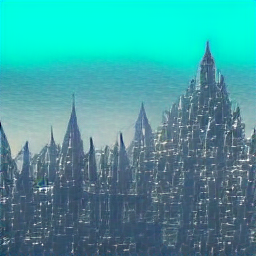

In [27]:
from PIL import Image

# Decode the final set of generated image tokens to an image
torch.cuda.empty_cache()
image2 = detokenizer.forward(True, image_tokens2[:, 1:])
image2 = image2.to(torch.uint8).to('cpu').numpy()
image2 = Image.fromarray(image2)
image2.save("files/minDALLE2.png")
image2


7. Display the $32$nd, $64$th, . . ., and $256$th images in the list `imgtokens2` that was created in Exercise 5 in a $2 \times 4$ grid.

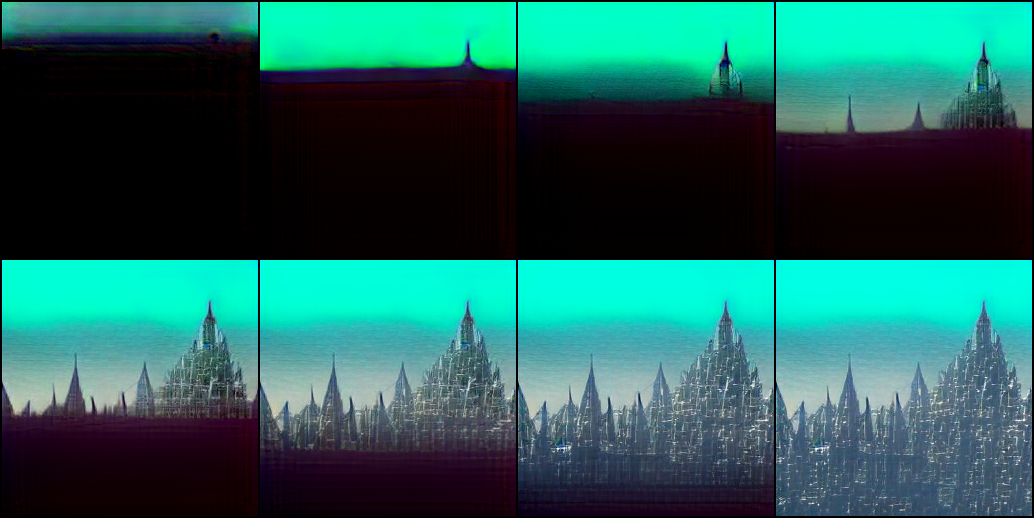

In [28]:
from torchvision.utils import make_grid
from torchvision.transforms import ToPILImage

# Collect and decode intermediate images at every 32 steps
imgs2 = []
for i in range(8):
    torch.cuda.empty_cache()
    images = detokenizer.forward(True, imgtokens2[32 * (i + 1) - 1][:, 1:])
    imgs2.append(images.permute(2, 0, 1).to(torch.uint8))

grid2 = make_grid(imgs2, nrow=4)
img2 = ToPILImage()(grid2)
img2.save("files/minDALLEsteps2.png")
img2


8. Generate an animation using the $256$ images in the list `imgtokens2` that was created
in Exercise 5.

In [29]:
vids2 = []
# Construct image sequence from all intermediate steps
for i in range(len(imgtokens2)):
    torch.cuda.empty_cache()
    images = detokenizer.forward(True, imgtokens2[i][:, 1:])
    image = images.to(torch.uint8).to('cpu').numpy()
    vids2.append(Image.fromarray(image))

import imageio
imageio.mimsave("files/minDALLE2.gif", vids2, fps=30)
